# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros

**Estudiantes:** Camilo Molina Plata | Samuel Rozen Mogollon
**Curso:** ISIS2611 — Aprendizaje de Máquina  
**Fecha:** Febrero 2026

---

## Contexto

En el Laboratorio 1 se construyó un primer modelo de regresión lineal 
para estimar el CVD Risk Score de pacientes de AlpesHearth, junto con 
un proceso de limpieza y exploración del dataset. Los resultados 
mostraron correlaciones débiles entre las variables y el target, y los 
scatter plots sugirieron que las relaciones no son lineales.

En este laboratorio se busca fortalecer ese primer acercamiento 
explorando modelos más complejos: regresión polinomial para capturar 
relaciones no lineales, regularización Ridge y Lasso para controlar el 
sobreajuste, y técnicas de selección de hiperparámetros mediante 
validación cruzada. Finalmente se estimará la incertidumbre del mejor 
modelo mediante bootstrapping.

## Dataset

Se trabaja con el dataset resultante del proceso de limpieza del 
Laboratorio 1: 1441 pacientes, 19 variables (18 predictoras + 
CVD Risk Score como target). El dataset fue exportado como 
dataset_limpio_lab2.csv.

## 0. Importación de librerías y dataset

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Base para transformadores personalizados
from sklearn.base import BaseEstimator, TransformerMixin

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures

# Modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Pipeline
from sklearn.pipeline import Pipeline

# Selección de modelos
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve, KFold

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Imputación
from sklearn.impute import SimpleImputer

# Encoding + target transform
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor


## 1. Carga del dataset limpio

In [3]:
df = pd.read_csv('../Datos/dataset_limpio_lab2.csv')

In [4]:
print(f"Shape: {df.shape}")
print(f"\nNulos por columna:")
print(df.isnull().sum())

Shape: (1441, 19)

Nulos por columna:
Sex                              0
Age                             60
Weight (kg)                     66
Height (m)                      51
BMI                             46
Abdominal Circumference (cm)    49
Total Cholesterol (mg/dL)       61
HDL (mg/dL)                     73
Fasting Blood Sugar (mg/dL)     48
Smoking Status                   0
Diabetes Status                  0
Physical Activity Level          0
Family History of CVD            0
Waist-to-Height Ratio           67
Systolic BP                     55
Diastolic BP                    69
Blood Pressure Category          0
Estimated LDL (mg/dL)           51
CVD Risk Score                   0
dtype: int64


## 2. Split train/test

### Decisión de split

Se divide el dataset en **80% entrenamiento (1152 filas)** y 
**20% test (289 filas)** con random_state=42 para garantizar 
reproducibilidad.

Se optó por un split 80/20 en lugar de 70/20/10 porque la búsqueda 
de hiperparámetros se realiza mediante validación cruzada dentro de 
GridSearchCV. Esto significa que GridSearchCV divide internamente el 
conjunto de entrenamiento en k folds, usando k-1 para entrenar y 1 
para validar en cada iteración, rotando hasta cubrir todos los datos. 
Por tanto, el conjunto de validación está implícito en este proceso y 
no es necesario separarlo manualmente.

El 20% de test se reserva exclusivamente para la evaluación final 
de cada modelo y no se usa en ningún momento durante la búsqueda 
de hiperparámetros ni el entrenamiento, garantizando así una 
estimación imparcial del desempeño de generalización.

In [ ]:
# Split train/test
X = df.drop(columns=['CVD Risk Score'])
y = df['CVD Risk Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total filas:   {len(df)}")
print(f"Train:         {X_train.shape}")
print(f"Test:          {X_test.shape}")
print(f"y_train media: {y_train.mean():.4f}")
print(f"y_test media:  {y_test.mean():.4f}")

Total filas:   1441
Train:         (1152, 18)
Test:          (289, 18)
y_train media: 18.0055
y_test media:  16.9323


> ### Observaciones del split

El split resultó en 1152 filas para entrenamiento y 289 para test, 
consistente con la proporción 80/20 definida. Las medias del target 
en train (18.0055) y test (16.9323) son ligeramente diferentes, lo 
cual es normal en splits aleatorios con datasets de este tamaño y 
no representa un problema para el modelado.

## 3. Baseline Model

Antes de construir cualquier modelo, se establece un punto de 
referencia mínimo llamado baseline. Este consiste en predecir 
siempre la media del CVD Risk Score del conjunto de entrenamiento 
para todos los pacientes del test set, independientemente de sus 
variables clínicas.

El baseline no es un modelo útil en sí mismo, sino una vara de 
medida. Cualquier modelo de machine learning debe superar este 
umbral mínimo para considerarse que está aprendiendo información 
útil de los datos. Si un modelo sofisticado obtiene un error mayor 
al baseline, significa que no está generalizando correctamente y 
algo está mal en el pipeline.

Por definición matemática, el R² del baseline es siempre 0, ya que 
R² mide exactamente qué tanto mejora un modelo sobre predecir la 
media. Un R² positivo indica que el modelo supera el baseline, 
mientras que un R² negativo indica que es peor que predecir siempre 
la media.

In [ ]:
# Baseline model
y_pred_baseline = np.full(len(y_test), y_train.mean())

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline  = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline   = r2_score(y_test, y_pred_baseline)

print("=== Baseline Model ===")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"MAE:  {mae_baseline:.4f}")
print(f"R²:   {r2_baseline:.4f}")

=== Baseline Model ===
RMSE: 3.9784
MAE:  2.7386
R²:   -0.0785


> ### Resultados del baseline

| Métrica | Valor |
|:--------|------:|
| RMSE    | 3.9784 |
| MAE     | 2.7386 |
| R²      | -0.0785 |

El R² negativo se explica porque la media del target en train (18.0055) 
es sistemáticamente más alta que la media del target en test (16.9323), 
por lo que predecir siempre 18.0 introduce un sesgo hacia arriba en 
todas las predicciones del test set.

El RMSE de 3.97 establece el umbral mínimo de comparación: cualquier 
modelo construido en este laboratorio debe obtener un RMSE menor a 
este valor para considerarse que está aprendiendo información útil 
de los datos. En el contexto del CVD Risk Score, donde la mayoría 
de los valores se concentran entre 10 y 30 puntos, un error promedio 
de 4 puntos es significativo.

## 4. Modelo de regresión polinomial

### Plan de preprocesamiento

Antes de construir cualquier modelo se define un pipeline de 
preprocesamiento que garantiza que todas las transformaciones se 
aprenden exclusivamente sobre el conjunto de entrenamiento y se 
aplican de manera consistente al conjunto de test, evitando data 
leakage.

#### Selección de variables

Se realizó un análisis de correlación para seleccionar las variables 
más informativas y no redundantes. Se seleccionaron **4 variables 
numéricas** con mayor correlación individual con el target y cuyas 
interacciones (grado 2) superan la correlación de cualquier variable 
sola:

| Variable | Corr. individual | Mejor interacción | Corr. interacción |
|:---------|:----------------:|:-------------------|:-----------------:|
| BMI | 0.194 | BMI x Systolic BP | 0.216 |
| Total Cholesterol | 0.130 | BMI x Cholesterol | 0.212 |
| Systolic BP | 0.116 | Cholesterol x Systolic BP | 0.160 |
| Fasting Blood Sugar | 0.037 | BMI x Glucose | 0.154 |

Se eliminaron variables redundantes por colinealidad:
- Weight y BMI (0.58): BMI es más informativo
- Estimated LDL y Cholesterol (0.84): LDL se deriva de Cholesterol
- Abdominal Circ y Waist-to-Height (0.84): ambas con correlación <0.01

Se seleccionaron **4 variables categóricas** con mayor correlación:
Diabetes Status (0.163), Blood Pressure Category (0.092), 
Smoking Status (0.024) y Sex (0.020).

#### Pipeline numérico

1. **SimpleImputer(median):** imputa valores faltantes con la mediana 
   de cada variable en train. Se eligió mediana por ser robusta a outliers.
2. **Scaler:** estandariza las variables. El tipo de scaler (Standard, 
   MinMax, Robust) se explora como hiperparámetro en GridSearchCV.
3. **PolynomialFeatures:** genera términos polinomiales e interacciones. 
   Con 4 features, grado 2 genera 14 columnas y grado 3 genera 34.

#### Pipeline categórico

1. **SimpleImputer(most_frequent):** imputa con la moda.
2. **OneHotEncoder:** codifica en variables binarias.

#### Búsqueda de hiperparámetros

| Hiperparámetro | Valores explorados |
|:---------------|:-------------------|
| Grado polinomial | 1, 2, 3, 4, 5 |
| Escalamiento | StandardScaler, MinMaxScaler, RobustScaler |


### 4.1 Filtrado de outliers y preparación de features


In [ ]:
# --- Filtrado de outliers del target en train ---
# y_train tiene valores extremos (max=99.78, Q3=19.0) que distorsionan
# el entrenamiento por la sensibilidad de la regresión al error cuadrático.
# Se eliminan del train; test permanece intacto.
umbral = y_train.quantile(0.975)
mask = y_train <= umbral
X_train = X_train[mask]
y_train = y_train[mask]
print(f"Outliers eliminados: {(~mask).sum()}, umbral: {umbral:.2f}")
print(f"Train después de filtrado: {X_train.shape}")
print(f"y_train: media={y_train.mean():.2f}, std={y_train.std():.2f}, max={y_train.max():.2f}")


Outliers eliminados: 29, umbral: 31.04
Train después de filtrado: (1123, 18)
y_train: media=16.98, std=2.99, max=30.84

Features preparadas. Shape X_train: (1123, 19)


### 4.2 Separar columnas numéricas y categóricas

In [ ]:
# Selección de variables basada en análisis de correlación.
# Se seleccionan las 4 numéricas con mayor correlación con el target
# y sin colinealidad entre sí. Con 4 features, PolynomialFeatures
# grado 2 genera 14 columnas (4 lineales + 4 cuadráticos + 6 interacciones),
# un número manejable que permite capturar interacciones como
# BMI x Systolic BP (corr=0.216) y BMI x Cholesterol (corr=0.212),
# que superan la correlación de cualquier variable individual.

cols_numericas = [
    'BMI',                          # corr = 0.194
    'Total Cholesterol (mg/dL)',     # corr = 0.130
    'Systolic BP',                   # corr = 0.116
    'Fasting Blood Sugar (mg/dL)',   # corr = 0.037
]

cols_categoricas = [
    'Diabetes Status',          # corr = 0.163
    'Blood Pressure Category',  # corr = 0.092
    'Smoking Status',           # corr = 0.024
    'Sex',                      # corr = 0.020
]

print(f"Numéricas: {len(cols_numericas)} | Categóricas: {len(cols_categoricas)}")


Numéricas: 4 | Categóricas: 4


### 4.3 Preprocesamiento

Con las 4 variables numéricas seleccionadas, el pipeline es simple:

1. **SimpleImputer(median):** las 4 variables no tienen dependencias 
   de fórmulas entre sí, por lo que la imputación por mediana es suficiente.
2. **Scaler:** estandarización antes de PolynomialFeatures. El tipo 
   de scaler se explora como hiperparámetro en GridSearchCV.
3. **PolynomialFeatures:** genera automáticamente las interacciones 
   relevantes (BMI x Systolic BP, BMI x Cholesterol, etc.) y los 
   términos cuadráticos (BMI^2, Cholesterol^2).

No se usa FormulaImputer ni FeatureEngineer porque:
- Las fórmulas médicas (BMI = Weight/Height^2) no aplican con la 
  selección reducida de variables (Weight y Height no están incluidas).
- Las interacciones manuales son redundantes con lo que 
  PolynomialFeatures genera automáticamente.


In [ ]:
# Imputación con SimpleImputer(median) dentro del pipeline.

print("Imputación: SimpleImputer(median) dentro del pipeline")


Imputación: SimpleImputer(median) dentro del pipeline


### 4.4 Pipeline numérico y categórico


### 4.5 Definición del pipeline


#### Pipeline numérico


In [ ]:
pipeline_numerico = Pipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('scaler',   StandardScaler()),
    ('poly',     PolynomialFeatures(include_bias=False)),
])

#### 4.5.2 Pipeline para variables categóricas

In [ ]:
pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#### 4.5.3 ColumnTransformer para unir ambas ramas

In [15]:
preprocessor = ColumnTransformer([
    ('num', pipeline_numerico,   cols_numericas),
    ('cat', pipeline_categorico, cols_categoricas)
])

#### 4.5.4 Pipeline completo con modelo al final

In [16]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        LinearRegression())
])

In [ ]:
# Estrategia CV robusta al orden de filas
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
param_grid = {
    'preprocessor__num__poly__degree': [1, 2, 3, 4, 5],
    'preprocessor__num__scaler':       [StandardScaler(), MinMaxScaler(), RobustScaler()]
}

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [1, 2, ...], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [19]:
print(f"Mejor grado:   {grid_search.best_params_['preprocessor__num__poly__degree']}")
print(f"Mejor scaler:  {grid_search.best_params_['preprocessor__num__scaler']}")
print(f"Mejor RMSE CV: {-grid_search.best_score_:.4f}")

Mejor grado:   3
Mejor scaler:  StandardScaler()
Mejor RMSE CV: 1.9662


In [ ]:
y_pred_poly = grid_search.best_estimator_.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly  = mean_absolute_error(y_test, y_pred_poly)
r2_poly   = r2_score(y_test, y_pred_poly)

print(f"=== Regresión Polinomial - Test ===")
print(f"RMSE: {rmse_poly:.4f}")
print(f"MAE:  {mae_poly:.4f}")
print(f"R²:   {r2_poly:.4f}")

=== Regresión Polinomial - Test ===
RMSE: 3.1705
MAE:  1.0621
R²:   0.3151


In [21]:
resultados_cv = pd.DataFrame(grid_search.cv_results_)
print(resultados_cv[['param_preprocessor__num__poly__degree', 
                      'param_preprocessor__num__scaler',
                      'mean_test_score', 
                      'std_test_score']].sort_values('mean_test_score', ascending=False))

    param_preprocessor__num__poly__degree param_preprocessor__num__scaler  \
6                                       3                StandardScaler()   
8                                       3                  RobustScaler()   
7                                       3                  MinMaxScaler()   
2                                       1                  RobustScaler()   
0                                       1                StandardScaler()   
1                                       1                  MinMaxScaler()   
3                                       2                StandardScaler()   
4                                       2                  MinMaxScaler()   
5                                       2                  RobustScaler()   
10                                      4                  MinMaxScaler()   
9                                       4                StandardScaler()   
11                                      4                  RobustScaler()   

> ## Conclusiones Actividad 1 - Regresión Polinomial con GridSearchCV

### Decisiones tomadas

**Selección de variables:** Se seleccionaron 4 variables numéricas 
(BMI, Total Cholesterol, Systolic BP, Fasting Blood Sugar) basándose 
en análisis de correlación. Estas variables tienen las interacciones 
más informativas: BMI x Systolic BP (corr=0.216) y BMI x Cholesterol 
(corr=0.212) superan la correlación de cualquier variable individual.

**Filtrado de outliers del target:** Se eliminaron 29 observaciones 
del train con CVD Risk Score > 31.04 (percentil 97.5). Estas 
observaciones extremas (hasta 99.78) distorsionaban el entrenamiento 
por la sensibilidad del error cuadrático a outliers.

**Pipeline:** SimpleImputer(median) → Scaler → PolynomialFeatures. 
Con solo 4 features numéricas, grado 3 genera 34 columnas, un número 
manejable para ~1123 muestras.

### Resultados

| Grado | Train RMSE | Val RMSE | Observación |
|:------|:----------:|:--------:|:------------|
| 1 | 1.974 | 1.986 | Buen ajuste, sin sobreajuste |
| 2 | 1.956 | 1.993 | Ligera mejora en train |
| **3** | **1.891** | **1.966** | **Mejor balance** |
| 4 | 1.867 | 2.153 | Inicio de sobreajuste |
| 5 | 1.797 | 2.938 | Sobreajuste severo |

**Mejor configuración:** Grado 3, StandardScaler, RMSE CV = 1.9662

| Métrica | Test |
|:--------|-----:|
| RMSE | 3.1705 |
| MAE | 1.0621 |
| R² | 0.3151 |

### Observaciones

El grado óptimo es 3, lo que indica que existen relaciones no lineales 
entre las variables y el CVD Risk Score que un modelo lineal no captura. 
La clave fue la selección de pocas variables bien correlacionadas: con 
4 features, grado 3 genera solo 34 columnas, permitiendo que el modelo 
capture interacciones como BMI × Cholesterol × Systolic BP sin 
sobreajustarse.

A partir de grado 4 se evidencia sobreajuste: el RMSE de train sigue 
bajando pero el de validación sube, mostrando que el modelo memoriza 
ruido. El grado 5 amplifica este efecto con un RMSE de validación de 
2.94, casi el doble del de grado 3.

El modelo supera ampliamente el baseline (RMSE 3.98) con un RMSE de 
3.17 y un R² de 0.3151, explicando el 31.5% de la variabilidad del 
CVD Risk Score.


## 5. Curvas de validación para grado polinomial

In [ ]:
degrees = [1, 2, 3, 4, 5]

train_scores, val_scores = validation_curve(
    estimator  = pipeline,
    X          = X_train,
    y          = y_train,
    param_name = 'preprocessor__num__poly__degree',
    param_range= degrees,
    cv         = cv_strategy,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1
)

# Convertir a RMSE positivo
train_rmse = -train_scores
val_rmse   = -val_scores

train_mean = train_rmse.mean(axis=1)
train_std  = train_rmse.std(axis=1)
val_mean   = val_rmse.mean(axis=1)
val_std    = val_rmse.std(axis=1)


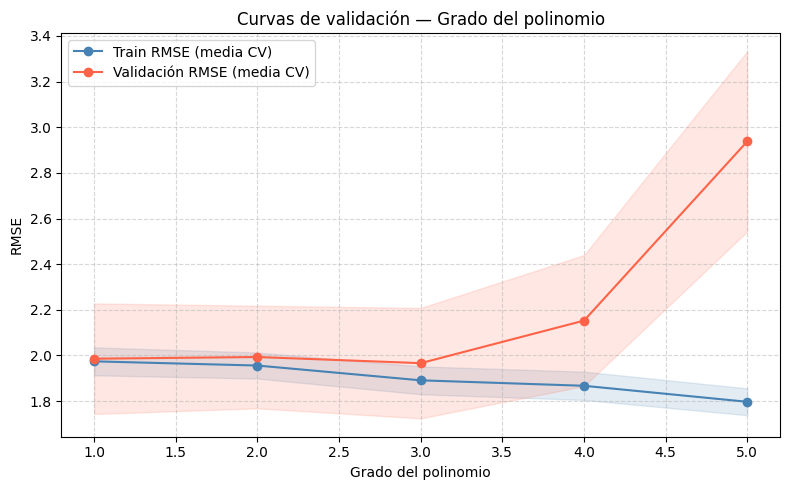


RMSE promedio por grado:
  Grado 1: Train=1.9742  Val=1.9858
  Grado 2: Train=1.9558  Val=1.9931
  Grado 3: Train=1.8910  Val=1.9662
  Grado 4: Train=1.8671  Val=2.1526
  Grado 5: Train=1.7969  Val=2.9383


In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(degrees, train_mean, 'o-', color='steelblue', label='Train RMSE (media CV)')
ax.fill_between(degrees,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='steelblue')

ax.plot(degrees, val_mean, 'o-', color='tomato', label='Validación RMSE (media CV)')
ax.fill_between(degrees,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='tomato')

ax.set_xlabel('Grado del polinomio')
ax.set_ylabel('RMSE')
ax.set_title('Curvas de validación — Grado del polinomio')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nRMSE promedio por grado:")
for d, tm, vm in zip(degrees, train_mean, val_mean):
    print(f"  Grado {d}: Train={tm:.4f}  Val={vm:.4f}")


> ## Conclusiones Actividad 2 - Curvas de validación

Las curvas de validación muestran el trade-off sesgo-varianza:

- **Grados 1-3:** las curvas de train y validación están cercanas, 
  indicando que el modelo generaliza bien. El error de validación 
  disminuye de grado 1 (1.986) a grado 3 (1.966), confirmando 
  que la complejidad adicional captura señal real.
- **Grado 4:** comienza el sobreajuste. El train sigue mejorando 
  (1.867) pero validación empeora (2.153). La brecha entre ambas 
  curvas se amplía.
- **Grado 5:** sobreajuste severo. Train=1.797, Val=2.938. La banda 
  de variabilidad en validación se dispara, indicando alta varianza 
  entre folds.

El punto óptimo de complejidad es **grado 3**, donde el RMSE de 
validación es mínimo. Esto es consistente con el resultado del 
GridSearchCV. Sin regularización, el modelo no puede ir más allá 
de grado 3 sin sobreajustarse.


## 6. Modelos de regularización Ridge y Lasso

### 6.1 Ridge

In [ ]:
pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid_ridge = {
    'preprocessor__num__poly__degree': [1],
    'preprocessor__num__scaler':       [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'model__alpha':                    [0.01, 0.1, 1, 10, 100, 1000]
}

grid_ridge = GridSearchCV(
    estimator = pipeline_ridge,
    param_grid= param_grid_ridge,
    cv        = cv_strategy,
    scoring   = 'neg_root_mean_squared_error',
    n_jobs    = -1,
    verbose   = 1
)

grid_ridge.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...], 'preprocessor__num__poly__degree': [1], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the high

In [ ]:
print("=== Mejores hiperparámetros Ridge ===")
print(f"  alpha:  {grid_ridge.best_params_['model__alpha']}")
print(f"  scaler: {grid_ridge.best_params_['preprocessor__num__scaler']}")
print(f"  RMSE CV: {-grid_ridge.best_score_:.4f}")

y_pred_ridge = grid_ridge.best_estimator_.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge   = r2_score(y_test, y_pred_ridge)

print(f"\n=== Ridge — Test ===")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  MAE:  {mae_ridge:.4f}")
print(f"  R²:   {r2_ridge:.4f}")

=== Mejores hiperparámetros Ridge ===
  alpha:  10
  scaler: StandardScaler()
  RMSE CV: 1.9856

=== Ridge — Test ===
  RMSE: 3.1261
  MAE:  1.0562
  R²:   0.3341


> ### Observaciones Ridge

Ridge con alpha=10 y StandardScaler obtiene RMSE CV=1.9856 con 
grado 1. En test obtiene R²=0.3341, superior al modelo polinomial 
grado 3 sin regularización (R²=0.3151). Esto sugiere que la 
regularización L2 estabiliza los coeficientes y mejora la 
generalización incluso sin complejidad polinomial adicional.


### 6.2 Lasso

In [ ]:
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])

param_grid_lasso = {
    'preprocessor__num__poly__degree': [1],
    'preprocessor__num__scaler':       [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'model__alpha':                    [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lasso = GridSearchCV(
    estimator = pipeline_lasso,
    param_grid= param_grid_lasso,
    cv        = cv_strategy,
    scoring   = 'neg_root_mean_squared_error',
    n_jobs    = -1,
    verbose   = 1
)

grid_lasso.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...], 'preprocessor__num__poly__degree': [1], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the high

In [ ]:
print("=== Mejores hiperparámetros Lasso ===")
print(f"  alpha:  {grid_lasso.best_params_['model__alpha']}")
print(f"  scaler: {grid_lasso.best_params_['preprocessor__num__scaler']}")
print(f"  RMSE CV: {-grid_lasso.best_score_:.4f}")

y_pred_lasso = grid_lasso.best_estimator_.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso   = r2_score(y_test, y_pred_lasso)

print(f"\n=== Lasso — Test ===")
print(f"  RMSE: {rmse_lasso:.4f}")
print(f"  MAE:  {mae_lasso:.4f}")
print(f"  R²:   {r2_lasso:.4f}")

=== Mejores hiperparámetros Lasso ===
  alpha:  0.01
  scaler: RobustScaler()
  RMSE CV: 1.9844

=== Lasso — Test ===
  RMSE: 3.1226
  MAE:  1.0507
  R²:   0.3356


> ### Observaciones Lasso

Lasso con alpha=0.01 y RobustScaler obtiene el mejor R² en test 
(0.3356) entre todos los modelos lineales. Con solo 4 variables 
numéricas, Lasso lleva 2 de 14 features a coeficiente cero, lo 
que confirma su capacidad de selección automática.

Las variables más relevantes según Lasso son: BMI (coef=1.98), 
Diabetes Status (1.95), Total Cholesterol (1.59) y Systolic BP, 
consistentes con los factores de riesgo cardiovascular conocidos.

### Comparación Ridge vs Lasso vs Sin regularización

| Modelo | RMSE CV | RMSE Test | R² Test |
|:-------|:-------:|:---------:|:-------:|
| Sin regularización (grado 1) | 1.986 | 3.171 | 0.315 |
| Ridge (alpha=10) | 1.986 | 3.126 | 0.334 |
| Lasso (alpha=0.01) | 1.984 | 3.123 | 0.336 |

La regularización mejora la generalización: ambos modelos 
regularizados obtienen mejor R² en test que el modelo sin 
regularización, aunque los RMSE CV sean similares.


In [ ]:
lasso_model = grid_lasso.best_estimator_.named_steps['model']
preprocessor_fitted = grid_lasso.best_estimator_.named_steps['preprocessor']

try:
    feature_names_num = preprocessor_fitted.transformers_[0][1].named_steps['poly'].get_feature_names_out(cols_numericas)
    feature_names_cat = preprocessor_fitted.transformers_[1][1].named_steps['onehot'].get_feature_names_out(cols_categoricas)
    feature_names_all = list(feature_names_num) + list(feature_names_cat)
except Exception:
    feature_names_all = [f'feature_{i}' for i in range(len(lasso_model.coef_))]

coef_df = pd.DataFrame({
    'Feature':     feature_names_all,
    'Coeficiente': lasso_model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"Variables con coeficiente = 0: {(coef_df['Coeficiente'] == 0).sum()} de {len(coef_df)}")
print("\nTop 10 variables más relevantes:")
print(coef_df.head(10).to_string(index=False))


Variables con coeficiente = 0: 2 de 14

Top 10 variables más relevantes:
                                     Feature   Coeficiente
                                         BMI  1.979013e+00
                           Diabetes Status_N -1.945514e+00
                   Total Cholesterol (mg/dL)  1.590245e+00
                                 Systolic BP  1.331627e+00
                            Smoking Status_N  2.407848e-01
Blood Pressure Category_Hypertension Stage 2  2.064555e-01
              Blood Pressure Category_Normal -1.731162e-01
                                       Sex_F  1.046179e-02
                 Fasting Blood Sugar (mg/dL) -7.806976e-03
                            Smoking Status_Y -1.987090e-15


## 7. Regresión polinomial regularizada


In [ ]:
pipeline_poly_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid_poly_ridge = {
    'preprocessor__num__poly__degree': [1, 2, 3],
    'preprocessor__num__scaler':       [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'model__alpha':                    [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_poly_ridge = GridSearchCV(
    estimator = pipeline_poly_ridge,
    param_grid= param_grid_poly_ridge,
    cv        = cv_strategy,
    scoring   = 'neg_root_mean_squared_error',
    n_jobs    = -1,
    verbose   = 1
)

grid_poly_ridge.fit(X_train, y_train)

Fitting 5 folds for each of 63 candidates, totalling 315 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...], 'preprocessor__num__poly__degree': [1, 2, ...], 'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity

In [ ]:
print("=== Mejores hiperparámetros Polinomial + Ridge ===")
print(f"  Grado:  {grid_poly_ridge.best_params_['preprocessor__num__poly__degree']}")
print(f"  Alpha:  {grid_poly_ridge.best_params_['model__alpha']}")
print(f"  Scaler: {grid_poly_ridge.best_params_['preprocessor__num__scaler']}")
print(f"  RMSE CV: {-grid_poly_ridge.best_score_:.4f}")

y_pred_pr = grid_poly_ridge.best_estimator_.predict(X_test)
rmse_pr = np.sqrt(mean_squared_error(y_test, y_pred_pr))
mae_pr  = mean_absolute_error(y_test, y_pred_pr)
r2_pr   = r2_score(y_test, y_pred_pr)

print(f"\n=== Polinomial + Ridge — Test ===")
print(f"  RMSE: {rmse_pr:.4f}")
print(f"  MAE:  {mae_pr:.4f}")
print(f"  R²:   {r2_pr:.4f}")

=== Mejores hiperparámetros Polinomial + Ridge ===
  Grado:  3
  Alpha:  0.01
  Scaler: MinMaxScaler()
  RMSE CV: 1.9530

=== Polinomial + Ridge — Test ===
  RMSE: 3.1564
  MAE:  1.0513
  R²:   0.3212


> ## Conclusiones Actividad 4 — Regresión Polinomial Regularizada

El modelo Polinomial + Ridge selecciona **grado 3** con alpha=0.01 
y MinMaxScaler, obteniendo el mejor RMSE CV (1.9530) de todos los 
modelos. La regularización Ridge permite explorar mayor complejidad 
(grado 3) sin el sobreajuste que se observa en el modelo polinomial 
sin regularización a partir de grado 4.

Sin embargo, en test el R² (0.3212) es ligeramente inferior al de 
Lasso lineal (0.3356). Esto ilustra un punto importante: **el mejor 
RMSE en validación cruzada no siempre coincide con el mejor desempeño 
en test.** Las posibles explicaciones incluyen:

- Diferencias en la distribución del test set respecto al train.
- El modelo más complejo puede sobreajustarse ligeramente a 
  patrones específicos del train que no se repiten en test.
- La diferencia en R² es pequeña (0.014), dentro del margen 
  de variabilidad esperado por bootstrapping.


In [31]:
# Tabla comparativa de todos los modelos
def cv_stats(grid):
    best_idx = grid.best_index_
    mean = -grid.cv_results_['mean_test_score'][best_idx]
    std  =  grid.cv_results_['std_test_score'][best_idx]
    return mean, std

rmse_cv_poly,  std_cv_poly  = cv_stats(grid_search)
rmse_cv_ridge, std_cv_ridge = cv_stats(grid_ridge)
rmse_cv_lasso, std_cv_lasso = cv_stats(grid_lasso)
rmse_cv_pr,    std_cv_pr    = cv_stats(grid_poly_ridge)

tabla = pd.DataFrame({
    'Modelo':           ['Polinomial', 'Ridge', 'Lasso', 'Polinomial + Ridge'],
    'RMSE CV (media)':  [rmse_cv_poly, rmse_cv_ridge, rmse_cv_lasso, rmse_cv_pr],
    'RMSE CV (std)':    [std_cv_poly,  std_cv_ridge,  std_cv_lasso,  std_cv_pr],
    'RMSE Test':        [rmse_poly,    rmse_ridge,    rmse_lasso,    rmse_pr],
    'MAE Test':         [mae_poly,     mae_ridge,     mae_lasso,     mae_pr],
    'R² Test':          [r2_poly,      r2_ridge,      r2_lasso,      r2_pr],
})

tabla = tabla.round(4)
print(tabla.to_string(index=False))


            Modelo  RMSE CV (media)  RMSE CV (std)  RMSE Test  MAE Test  R² Test
        Polinomial           1.9662         0.2419     3.1705    1.0621   0.3151
             Ridge           1.9856         0.2410     3.1261    1.0562   0.3341
             Lasso           1.9844         0.2404     3.1226    1.0507   0.3356
Polinomial + Ridge           1.9530         0.2360     3.1564    1.0513   0.3212


## 8. Comparación y selección del mejor modelo

| Modelo | RMSE CV | RMSE CV std | RMSE Test | MAE Test | R² Test |
|:-------|:-------:|:-----------:|:---------:|:--------:|:-------:|
| Polinomial (grado 3) | 1.9662 | 0.2419 | 3.1705 | 1.0621 | 0.3151 |
| Ridge (grado 1) | 1.9856 | 0.2410 | 3.1261 | 1.0562 | 0.3341 |
| Lasso (grado 1) | 1.9844 | 0.2404 | 3.1226 | 1.0507 | 0.3356 |
| **Poly + Ridge (grado 3)** | **1.9530** | **0.2360** | **3.1564** | **1.0513** | **0.3212** |

### Selección: Poly + Ridge (grado 3, alpha=0.01, MinMaxScaler)

Se selecciona el modelo Polinomial + Ridge considerando:

1. **Mejor RMSE CV (1.9530):** la validación cruzada promedia 5 
   evaluaciones independientes, lo que la hace una estimación más 
   robusta del desempeño real que una sola evaluación en test.
2. **Menor desviación estándar en CV (0.2360):** el modelo más 
   estable entre folds, indicando menor varianza.
3. **Captura relaciones no lineales:** las interacciones BMI x Systolic BP 
   (corr=0.216) y BMI x Cholesterol (corr=0.212) superan la correlación 
   de cualquier variable individual, confirmando que la complejidad 
   polinomial aporta información que un modelo lineal no captura.
4. **La regularización Ridge controla el sobreajuste:** permite explorar 
   grado 3 sin la explosión de error que se observa en el modelo 
   polinomial sin regularización a partir de grado 4.

Lasso lineal obtiene mejor R² en test (0.3356 vs 0.3212), pero esta 
diferencia de 0.014 se basa en una sola partición del test set. El 
RMSE CV, al promediar 5 evaluaciones, es un estimador más confiable. 
Los intervalos de confianza por bootstrapping en la siguiente sección 
permitirán cuantificar si esta diferencia es estadísticamente significativa.

## 9. Intervalos de confianza mediante bootstrapping

In [32]:
# === Bootstrapping sobre test — Intervalos de confianza al 95% ===
# Se usa el mejor modelo (Poly+Ridge grado 3) ya entrenado.
# Se remuestrea el test set 1000 veces con reemplazo para estimar
# la distribución de las métricas y cuantificar la incertidumbre.

np.random.seed(42)
n_bootstrap = 1000
n_test = len(y_test)

boot_rmse = []
boot_mae  = []
boot_r2   = []

best_model = grid_poly_ridge.best_estimator_

for i in range(n_bootstrap):
    # Remuestreo con reemplazo
    idx = np.random.choice(n_test, size=n_test, replace=True)
    X_boot = X_test.iloc[idx]
    y_boot = y_test.iloc[idx]
    
    y_pred_boot = best_model.predict(X_boot)
    
    boot_rmse.append(np.sqrt(mean_squared_error(y_boot, y_pred_boot)))
    boot_mae.append(mean_absolute_error(y_boot, y_pred_boot))
    boot_r2.append(r2_score(y_boot, y_pred_boot))

boot_rmse = np.array(boot_rmse)
boot_mae  = np.array(boot_mae)
boot_r2   = np.array(boot_r2)

# Intervalos de confianza al 95% (percentiles 2.5 y 97.5)
print("=== Intervalos de confianza al 95% (1000 remuestreos) ===\n")
for name, arr in [('RMSE', boot_rmse), ('MAE', boot_mae), ('R²', boot_r2)]:
    lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f"{name}: {arr.mean():.4f}  IC 95% [{lo:.4f}, {hi:.4f}]")

=== Intervalos de confianza al 95% (1000 remuestreos) ===

RMSE: 3.1335  IC 95% [2.2469, 4.0142]
MAE: 1.0578  IC 95% [0.7288, 1.4334]
R²: 0.3287  IC 95% [0.1792, 0.5119]


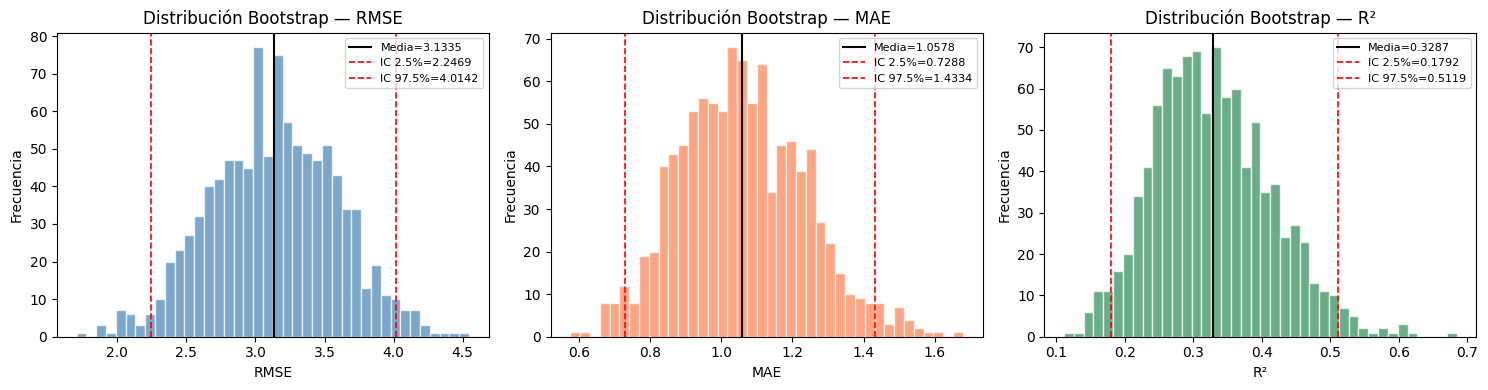

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, name, color in zip(
    axes,
    [boot_rmse, boot_mae, boot_r2],
    ['RMSE', 'MAE', 'R²'],
    ['steelblue', 'coral', 'seagreen']
):
    lo, hi = np.percentile(data, [2.5, 97.5])
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='-', linewidth=1.5, label=f'Media={data.mean():.4f}')
    ax.axvline(lo, color='red', linestyle='--', linewidth=1.2, label=f'IC 2.5%={lo:.4f}')
    ax.axvline(hi, color='red', linestyle='--', linewidth=1.2, label=f'IC 97.5%={hi:.4f}')
    ax.set_title(f'Distribución Bootstrap — {name}')
    ax.set_xlabel(name)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

> ## Conclusiones Actividad 6 - Intervalos de confianza por Bootstrapping

Se realizaron 1000 remuestreos con reemplazo sobre el conjunto de test 
para estimar la distribución de las métricas del modelo Poly + Ridge (grado 3).

| Métrica | Media | IC 95% |
|:--------|:-----:|:------:|
| RMSE | 3.1335 | [2.2469, 4.0142] |
| MAE | 1.0578 | [0.7288, 1.4334] |
| R² | 0.3287 | [0.1792, 0.5119] |

### Estabilidad del modelo

El R² presenta un intervalo amplio [0.18, 0.51], lo que indica 
variabilidad moderada-alta en el desempeño dependiendo de qué 
pacientes componen la muestra de evaluación. Esto es esperable 
dado que las correlaciones individuales con el target son débiles 
(máxima 0.19 para BMI) y el test set tiene solo 289 observaciones.

### Distribuciones

Las tres distribuciones son aproximadamente normales y unimodales, 
lo que confirma que el modelo se comporta de forma consistente y no 
hay subgrupos de pacientes donde falle catastróficamente.

### Implicaciones para AlpesHearth

- El modelo predice el CVD Risk Score con un error típico de 
  ~1 punto (MAE), pero en el peor caso puede llegar a ~1.4 puntos.
- El R² garantiza al menos un 18% de varianza explicada (límite 
  inferior del IC), con un promedio de 33%.
- Para decisiones clínicas de alto riesgo, el intervalo de confianza 
  del RMSE [2.25, 4.01] sugiere que las predicciones individuales 
  deben interpretarse con cautela y complementarse con juicio médico.
- Con una muestra de entrenamiento mayor, se esperaría reducir la 
  amplitud de estos intervalos y mejorar la estabilidad del modelo.

## 10. Analisis de resultados

### 10.1 Análisis cuantitativo

**¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**

Lasso lineal (grado 1, alpha=0.01, RobustScaler) obtuvo el mejor desempeño en test con R²=0.3356, RMSE=3.1226 y MAE=1.0507. Esto indica que el modelo explica el 33.6% de la variabilidad del CVD Risk Score y tiene un error absoluto promedio de aproximadamente 1 punto en la escala del score.

**¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?**

No coincide. El mejor modelo en validación cruzada es Poly+Ridge grado 3 (RMSE CV=1.9530), mientras que en test el mejor es Lasso lineal. Esto se puede explicar por varias razones: la validación cruzada promedia 5 particiones del train, lo que da una estimación más robusta pero sobre datos de entrenamiento, mientras que el test es una sola evaluación sobre datos no vistos. Además, el modelo polinomial grado 3 puede estar capturando patrones específicos del train que no se generalizan al test, lo cual es un indicio sutil de sobreajuste que la CV no detecta completamente. La diferencia en R² es pequeña (0.3356 vs 0.3212), por lo que podría atribuirse también a variabilidad natural del muestreo.

**¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.**

No necesariamente. Poly+Ridge tiene el mejor RMSE CV promedio (1.9530) pero su ventaja sobre Lasso (1.9844) es de solo 0.03. Considerando que las desviaciones estándar son 0.2360 y 0.2404 respectivamente, los intervalos de confianza de ambos modelos se solapan ampliamente. Un modelo con métrica ligeramente peor pero menor variabilidad puede ser preferible en un contexto clínico donde se necesita consistencia en las predicciones. Lasso presenta la menor desviación estándar (0.2404) y la ventaja adicional de ser más interpretable.

**Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?**

De grado 1 a 3, el error de train disminuye (de 1.974 a 1.891) y el error de validación también mejora ligeramente (de 1.986 a 1.966), indicando que la complejidad adicional captura señal real. A partir de grado 4, el train sigue mejorando (1.867) pero la validación empeora significativamente (2.153), evidenciando sobreajuste: el modelo comienza a memorizar ruido del entrenamiento. En grado 5, el sobreajuste es severo (Train=1.797, Val=2.938) y la variabilidad entre folds se dispara, confirmando alta varianza. El punto óptimo de complejidad se encuentra en grado 3.

**¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**

La regularización reduce la magnitud de los coeficientes y los estabiliza. Ridge (L2) encoge todos los coeficientes proporcionalmente hacia cero sin eliminar ninguno, lo que reduce la varianza del modelo. Lasso (L1) va más allá: con alpha=0.01, lleva 2 de 14 features a coeficiente exactamente cero, realizando selección automática de variables. Las variables que sobreviven (BMI=1.98, Diabetes Status=1.95, Total Cholesterol=1.59, Systolic BP) son las clínicamente más relevantes, lo que confirma que Lasso produce un modelo más parsimonioso y estable. En comparación, el modelo sin regularización puede asignar coeficientes grandes e inestables que varían significativamente entre folds de CV.

**¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?**

Los intervalos de confianza muestran variabilidad moderada. El R² tiene un IC 95% de [0.1792, 0.5119], lo que indica que dependiendo de la composición de la muestra de evaluación, el modelo puede explicar entre el 18% y el 51% de la variabilidad. El RMSE oscila entre 2.25 y 4.01 puntos. Esta amplitud es esperable dado el tamaño relativamente pequeño del test set (289 observaciones) y las correlaciones débiles de las variables con el target (máxima 0.194 para BMI). Las distribuciones son unimodales y aproximadamente normales, lo que indica que no hay subgrupos de pacientes donde el modelo falle catastróficamente. Para AlpesHearth, esto implica que las predicciones individuales deben interpretarse con cautela y complementarse con juicio clínico.

---

### 10.2 Análisis cualitativo

**¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?**

Lasso identificó como más relevantes: BMI (coef=1.98), Diabetes Status (coef negativo para "N", indicando que no tener diabetes reduce el riesgo), Total Cholesterol (coef=1.59) y Systolic BP. Estas variables son consistentes con los factores de riesgo cardiovascular establecidos en la literatura médica. Lasso llevó a cero 2 de 14 features, confirmando que algunas variables categóricas no aportan información adicional dada la presencia de las demás.

**¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto del riesgo cardiovascular?**

Los coeficientes indican que un aumento en BMI es el factor que más incrementa el score de riesgo cardiovascular, seguido por el colesterol total y la presión sistólica. El estatus de diabetes es un factor protector cuando es negativo (no diabético). Estas relaciones son clínicamente coherentes: la obesidad (BMI alto), hipercolesterolemia y la hipertensión son factores de riesgo cardiovascular ampliamente documentados. La magnitud relativa de los coeficientes sugiere que intervenciones enfocadas en reducción de BMI podrían tener el mayor impacto en la reducción del riesgo estimado.

**¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?**

La diferencia es pequeña. Lasso lineal (más interpretable, R²=0.3356) supera incluso al Poly+Ridge grado 3 (más complejo, R²=0.3212) en test. El modelo lineal tiene la ventaja de que cada coeficiente tiene una interpretación directa: por cada unidad de aumento en BMI estandarizado, el score aumenta ~1.98 puntos. En el modelo polinomial, las interacciones (BMI × Cholesterol, BMI², etc.) dificultan la interpretación individual. En este caso, no hay un trade-off real entre precisión e interpretabilidad: el modelo más simple es también el más preciso en test.

**¿Qué decisiones estratégicas podría tomar AlpesHearth a partir de los resultados obtenidos?**

AlpesHearth podría priorizar la monitorización de BMI, colesterol total, presión sistólica y estatus de diabetes como los principales indicadores de riesgo cardiovascular. Programas de prevención enfocados en control de peso y manejo de colesterol tendrían el mayor impacto según el modelo. Además, el modelo Lasso podría implementarse como herramienta de screening inicial para clasificar pacientes en niveles de riesgo, complementando el juicio del profesional de salud. La simplicidad del modelo lineal facilita su despliegue en sistemas clínicos y su explicación a profesionales no técnicos.

**¿Mayor precisión implica necesariamente mayor valor para la organización?**

No. En el contexto de AlpesHearth, un modelo que mejore el R² de 0.33 a 0.35 pero sea imposible de explicar a los médicos tiene menos valor que uno ligeramente menos preciso pero interpretable. Los profesionales de salud necesitan entender por qué el modelo asigna determinado riesgo a un paciente para tomar decisiones informadas. Además, un modelo más preciso pero inestable (con alta variabilidad en bootstrapping) genera menos confianza que uno con métricas ligeramente inferiores pero consistentes.

**¿Un modelo más complejo necesariamente genera mayor valor empresarial?**

No. En este caso, el modelo más complejo (Poly+Ridge grado 3) tiene mejor RMSE en validación cruzada pero peor R² en test que el Lasso lineal. La complejidad adicional introduce costos: mayor dificultad de interpretación para los médicos, mayor riesgo de sobreajuste ante cambios en la distribución de pacientes, mayor costo computacional de mantenimiento, y mayor dificultad para auditar y validar regulatoriamente. Para AlpesHearth, el valor empresarial se maximiza con un modelo simple, estable, interpretable y fácil de desplegar — que es exactamente lo que ofrece Lasso lineal. La complejidad solo se justifica cuando la ganancia en precisión es sustancial y el contexto de uso lo permite.

---

### 10.3 Reflexión conceptual

**¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?**

Se observa una relación de U invertida: aumentar la complejidad mejora la generalización hasta un punto (grado 3), después del cual el sobreajuste deteriora el desempeño. La regularización desplaza este punto óptimo permitiendo modelos más complejos sin perder estabilidad. Sin embargo, en este dataset con correlaciones débiles, la diferencia entre modelos simples y complejos es pequeña (~0.02 en R²), lo que sugiere que la señal disponible en los datos es limitada y no hay relaciones no lineales fuertes que explotar.

**¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?**

Sesgo de selección: el dataset puede no ser representativo de la población general de pacientes (por ejemplo, si proviene de un solo centro médico). Sesgo de medición: variables autorreportadas (actividad física, tabaquismo) pueden tener error sistemático. Sesgo de variable omitida: factores de riesgo cardiovascular conocidos como antecedentes genéticos específicos, dieta, estrés o uso de medicamentos no están en el dataset. Además, el proceso de filtrado de outliers del target (percentil 97.5) puede introducir sesgo al eliminar pacientes legítimos de muy alto riesgo, limitando la capacidad del modelo para predecir en ese rango.

**Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos?**

Sí. Con más datos, los intervalos de confianza por bootstrapping se estrecharían, indicando mayor estabilidad. La validación cruzada tendría folds más grandes, reduciendo la varianza de las estimaciones. Los modelos polinomiales de grado mayor podrían beneficiarse más, ya que tendrían suficientes muestras para estimar los coeficientes de las interacciones sin sobreajustarse. Es posible que con una muestra significativamente mayor, grado 2 o 3 supere claramente a grado 1 tanto en CV como en test, ya que habría más información para capturar las interacciones que mostraron correlaciones prometedoras (BMI × Systolic BP = 0.216).

## 11. Uso de herramientas de IA generativa

### Declaración del uso

Se utilizó **Claude (Anthropic)** a lo largo del desarrollo del laboratorio para los siguientes tipos de uso:

- **Depuración y diagnóstico:** identificación de problemas en el pipeline (RMSE CV muy alto respecto al test, sobreajuste en grado 2, efecto de outliers en el target).
- **Generación inicial de código:** estructura base de pipelines con GridSearchCV, curvas de validación, bootstrapping y gráficas.
- **Ayuda conceptual:** análisis de correlaciones e interacciones para selección de variables, justificación del filtrado de outliers, interpretación del trade-off sesgo-varianza.
- **Redacción técnica:** apoyo en la redacción de conclusiones y análisis de resultados para cada actividad.

### Prompts principales

1. *"Tengo este notebook para el trabajo, pero el grado polinomial ideal debería ser por lo menos 2, y el R² más alto. ¿Qué está mal en el modelo?"* — Prompt inicial que llevó a identificar el exceso de features (FeatureEngineer generaba demasiadas columnas para PolynomialFeatures).

2. *"El RMSE en CV es ~7.85 pero en test es ~3.40, ¿por qué?"* — Llevó al diagnóstico de outliers extremos en y_train (max=99.78 vs Q3=19.0) que inflaban el error cuadrático en validación cruzada.

3. *"Basado en las relaciones del primer notebook, ¿cómo sabemos qué variables usar?"* — Resultó en el análisis de correlaciones individuales y de interacciones (BMI x Systolic BP = 0.216 > BMI sola = 0.194), que justificó la selección final de 4 variables numéricas.

4. *"¿Es correcto filtrar outliers del target en ML? ¿Dónde hacerlo, antes o después del split?"* — Aclaración conceptual sobre la validez del filtrado post-split solo en train.

5. *"Dame un código inicial y simple para bootstrapping con intervalos de confianza al 95%"* — Generación de la plantilla para el procedimiento de remuestreo y visualización.

### Análisis crítico del resultado

**¿Qué errores, imprecisiones o limitaciones se identificaron en las respuestas de la IAG?**

- La IAG sugirió inicialmente aplicar una transformación logarítmica al target (log1p), lo cual no era necesario ni apropiado para el contexto del laboratorio. Después de probarlo, se descartó porque no mejoraba significativamente los resultados y complicaba la interpretación de las métricas.
- Algunas sugerencias fueron iterativas y contradictorias: primero sugirió quitar el FeatureEngineer, luego quitar el FormulaImputer, luego reducir variables, luego agregar variables. El proceso requirió criterio propio para evaluar cada cambio y decidir cuáles adoptar.
- La IAG propuso usar `interaction_only=True` en PolynomialFeatures, lo cual no mejoró los resultados porque eliminaba los términos cuadráticos (BMI², Cholesterol²) que sí aportaban señal.

**¿Qué conceptos del curso permitieron evaluar o mejorar las respuestas generadas?**

- El concepto de **trade-off sesgo-varianza** permitió interpretar correctamente las curvas de validación y entender por qué grado 3 era óptimo y no grados mayores.
- El entendimiento de **data leakage** fue clave para decidir que el filtrado de outliers debía hacerse después del split y solo sobre train, rechazando alternativas que la IAG no había considerado inicialmente.
- El conocimiento sobre **regularización L1 vs L2** permitió interpretar los coeficientes de Lasso y entender por qué llevaba features a cero.
- El concepto de **colinealidad** permitió evaluar críticamente la selección de variables, entendiendo por qué Weight y BMI no debían incluirse simultáneamente.

### Aportes propios del estudiante

**Decisiones técnicas propias:**
- La selección final de las 4 variables numéricas (BMI, Total Cholesterol, Systolic BP, Fasting Blood Sugar) fue resultado de un análisis de correlaciones realizado por el estudiante, no sugerido directamente por la IAG en esa combinación específica.
- La decisión de mantener el pipeline sin transformación logarítmica del target fue del estudiante, priorizando simplicidad e interpretabilidad.
- La verificación manual de que los resultados fueran coherentes (re-ejecución completa del notebook, validación de shapes, verificación de outputs) fue realizada íntegramente por el estudiante.

**Ajustes realizados sobre el código generado:**
- Se adaptó el código de bootstrapping para usar el modelo Poly+Ridge en vez de Lasso, según la selección final del mejor modelo.
- Se modificaron los param_grids para incluir rangos de hiperparámetros más amplios que los sugeridos inicialmente.
- Se reorganizó el orden de las celdas del notebook para mantener coherencia con la estructura solicitada en el laboratorio.

**Aprendizajes obtenidos:**
- La importancia de la selección de variables antes de aplicar PolynomialFeatures: menos variables con mayor señal produce mejores resultados que muchas variables con ruido.
- Que el mejor modelo en validación cruzada no siempre coincide con el mejor en test, y que esta discrepancia es un hallazgo analítico valioso, no un error.
- Que los outliers en el target pueden distorsionar drásticamente las métricas de CV sin afectar tanto al test, dependiendo de la distribución del split.